# LTAT.02.006 Andmeteaduse meetodid

## 10. praktikum - Bayesi statistika


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### Ülesanne

Me näeme mündivisete seeria tulemusi, kuid me ei tea, mis tõenäosusega on kasutataud mündil kulli saamise tõenäosus. Me teame ainult, et münt valiti juhuslikult karbist, kus on 11 münti, mille kulli saamise tõenäosused on 0, 0.1, ..., 0.9 ja 1.

Meil on vaja ennustada, kui suur on tõenäosus saada kull järgmisel viskel sama mündiga.

### Eeljaotus - $P(M)$

Meetod, mille abil valitakse juhuslik münt, defineerib Bayesi statistika terminoloogiat kasutades **eeljaotuse**. Tõenäosus, et karbist tõmmatakse mingi kindel münt, on $\frac{1}{11}$. Sümbolitega väljendades saame kirjutada nii:

$$ P(M=p)=\frac{1}{11}, \quad p \in \{0, 0.1, ... 0.9, 1\} $$


In [40]:
mündid = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

def p_münt(p_kull):
    if p_kull not in mündid:
        raise ValueError("p_kull peab olema müntide hulgas")

    return 1 / len(mündid)

In [41]:
p_münt(p_kull=0.5)

0.09090909090909091

### Andmed tingimusel mudel - $P(D|M)$

Kui me teame, milline münt valiti, siis kui suure tõenäosusega tulevad just sellised visketulemused?


In [44]:
#import math

def p_visked_münt(visked, p_kull):
    p = 1

    for vise in visked:
        if vise == 1:
            p *= p_kull
        else:
            p *= 1 - p_kull

    return p


p_visked_münt(visked = [0, 1], p_kull = 0.5)

0.25

### Andmete tõenäosus - $P(D)$

Kui me ei tea, milline münt valiti, siis kui suure tõenäosusega tulevad just sellised visketulemused?

$$ P(D) = \sum_M{P(D|M)P(M)} $$


In [45]:
def p_visked(visked):
    p = 0
    for münt in mündid:
        p += p_visked_münt(visked, münt) * p_münt(münt)

    return p

p_visked(visked = [0, 1])

0.15000000000000002

### Järeljaotus - $P(M|D)$

Enne visketulemuste nägemist teame vaid, et igal mündil on võrdne tõenäosus saada valitud ja seda tõenäosust nimetatakse **eeljaotuseks**. Kui me oleme näinud visete seeriat eeljaotusest valitud mündiga, saame uuendada enda hinnangut selle osas, milline münt valiti. Seda uuendatud hinnangut nimetatakse Bayesi statistikas **järeljaotuseks** ja selle arvutamiseks saame kasutada Bayesi reeglit:

$$ P(M|D) = \frac{P(D|M)P(M)}{P(D)} $$


In [48]:
def p_münt_visked(p_kull, visked):
	p_D = p_visked(visked)
	p_D_M = p_visked_münt(visked, p_kull)
	P_M = p_münt(p_kull)

	return (p_D_M * P_M) / p_D

p_münt_visked(p_kull = 0.5, visked = [0, 1])

0.1515151515151515

In [60]:
p_münt_visked(0.5, [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

0.0008961742856164916

### Ennustus - $P(Y|D)$

Tahame ennustada tõenäosust, et järgmise viske tulemus on kull ($Y=1$), kui kasutada sama münti millega vaadeldud visked tehti. Bayesi statistikas pannakse see kirja nii:

$$ P(Y|D) = \sum_M P(Y|M)P(M|D) $$

Kuna meie näites mudeliks on münt, millel on vaid üks parameeter $p$, siis $P(Y|M) = P(Y=1|M=p) = p$.


In [57]:
def ennusta_münt(visked):
    #for vise in visked:
    #    if vise not in [0, 1]:
    #        raise ValueError("Visked peavad olema 0 või 1")

    p_Y_D = 0
    for münt in mündid:
       p_Y_D += p_münt_visked(münt, visked) * münt

    return p_Y_D

Vaatleme nüüd erinevaid näiteid visete seeriatest ja ennustustame nende seeriate järgmise viske kulli tõenäosust.


In [ ]:
ennusta_münt([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

0.14092460500977833

### Järeljaotuse visualiseerimine

Võrdleme eeljaotuse ja järeljaotuse tõenäosusfunktsioone tulpdiagrammidena.


In [62]:
visked = [1, 0, 0]

eeljaotus = [p_münt(münt) for münt in mündid]
järeljaotus = [p_münt_visked(münt, visked) for münt in mündid]

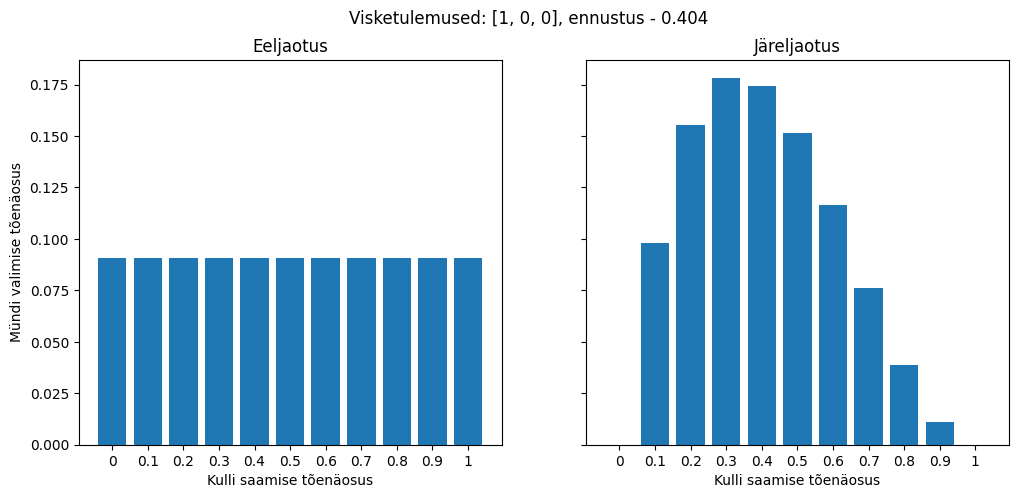

In [63]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5), sharey=True)
fig.suptitle(f"Visketulemused: {visked}, ennustus - {ennusta_münt(visked):3g}")

axs[0].bar(x = range(len(mündid)), height = eeljaotus)
axs[0].set_xticks(ticks = range(len(mündid)), labels = mündid)
axs[0].set_title("Eeljaotus")
axs[0].set_xlabel("Kulli saamise tõenäosus")
axs[0].set_ylabel("Mündi valimise tõenäosus")

axs[1].bar(x = range(len(mündid)), height = järeljaotus)
axs[1].set_xticks(ticks = range(len(mündid)), labels = mündid)
axs[1].set_title("Järeljaotus")
axs[1].set_xlabel("Kulli saamise tõenäosus")

plt.show()

### Kui eeljaotus oleks pidev

Oletame nüüd, et kulli saamise tõenäosus tõmmatakse pidevast ühtlasest jaotusest. Milline näeks välja järeljaotus, kui vaatlesime $h$ kulli ja $t$ kirja?

Tuleb välja, et selleks on beetajaotus parameetritega $\alpha = h + 1$ ja $\beta = b + 1$. Järgmise viske ennustus on siis järeljaotuse keskväärtus.

Visualiseerime eel- ja järeljaotused ning teeme ennustuse scipy teegi abil.


In [73]:
kullide_arv = 1
kirjade_arv = 3

eeljaotus_pidev = stats.uniform(loc = 0, scale = 1)
järeljaotus_pidev = stats.beta(a = kullide_arv + 1, b = kirjade_arv + 1)
ennustus = järeljaotus_pidev.expect()

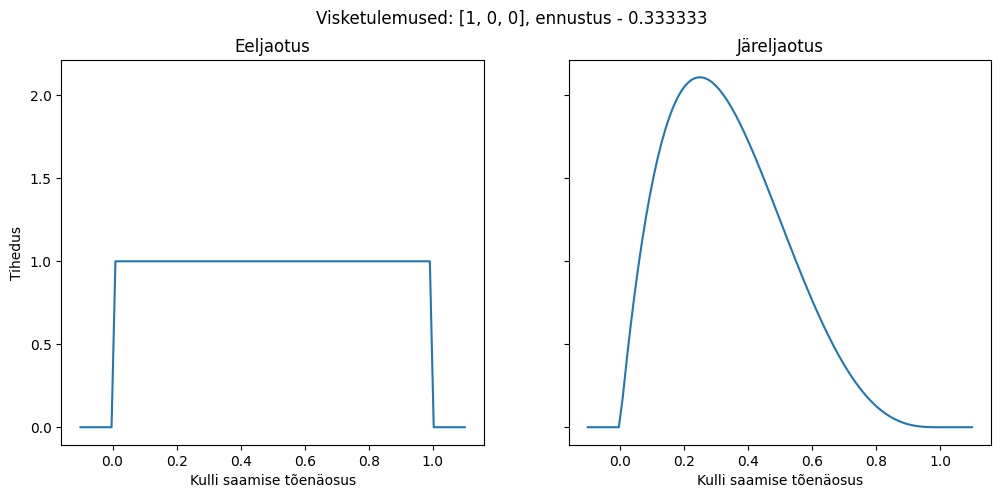

In [74]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5), sharey=True)
fig.suptitle(f"Visketulemused: {visked}, ennustus - {ennustus:3g}")

x_telg = np.linspace(-0.1, 1.1, 100)

axs[0].plot(x_telg, eeljaotus_pidev.pdf(x_telg))
axs[0].set_title("Eeljaotus")
axs[0].set_ylabel("Tihedus")
axs[0].set_xlabel("Kulli saamise tõenäosus")

axs[1].plot(x_telg, järeljaotus_pidev.pdf(x_telg))
axs[1].set_title("Järeljaotus")
axs[1].set_xlabel("Kulli saamise tõenäosus")

plt.show()

## Empiiriliselt parim strateegia

Su sõbral on needsamad ülalmainitud 11 münti, mis näevad välja samasugused, aga tegelikult on neil kõigil erinev tõenäosus saada kull.

Sõber valib ühtlaselt juhuslikult ühe nendest müntidest ning viskab seda münti. Sa näed tulemust (kull või kiri) ja pead ära arvama, et mis on sama mündiga tehtud järgmise mündiviske tulemus (ikka veel teadmata milline 11st mündist see on). Sa mängid seda mängu oma sõbraga 1000 korda, iga kord samade 11 mündiga. Ennustamisel saab pakkuda suvalisi reaalarve vahemikust [0, 1]. Kui 1000 mängu on mängitud, siis hinnatakse ennustusi mõõduga MSE (mean squared error) ehk keskmise ruutveaga.

Kui MSE < 0.1, siis võidad mängu Sina, vastasel juhul võidab sõber.
Selle ülesande eesmärk on leida empiiriliselt optimaalne strateegia.

Proovige erinevaid strateegiaid, nt:

1. alati 0.5
2. viimase viske tulemus
3. kulli tulemise sagedus: loeme kokku kullide arvu ja jagame visete arvuga
4. Bayesi mudelite keskmistamine

Proovida ka mängu modifikatsiooni, kus igas 1000-st alammängust visatakse
münti mitte 1 kord vaid k korda ning on vaja ennustada tulemus neile järgneval korral.


In [147]:
rng = np.random.default_rng(0)

visete_arv = 100
ennustuste_arv = 1000

ennustused = np.zeros(ennustuste_arv)
märgendid = np.zeros(ennustuste_arv)

for i in range(ennustuste_arv):
    p_kull = rng.choice(mündid)
    visked = rng.choice([0, 1], p = [1-p_kull, p_kull], size = visete_arv + 1)

    vaadeldud_visked = visked[:-1]
    märgendid[i] = visked[-1]

    # 1 - alati 0.5
    #ennustused[i] = 0.5

    # 2 - viimase viske tulemus
    #ennustused[i] = vaadeldud_visked[-1]

    # 3 - kulli tulemise sagedus: loeme kokku kullide arvu ja jagame visete arvuga
    #ennustused[i] = np.sum(vaadeldud_visked == 1) / len(vaadeldud_visked)

    # 4 - Bayesi mudelite keskmistamine
    #ennustused[i] = ennusta_münt(vaadeldud_visked)

    # Boonus - optimaalne ennustus viimase viske põhjal
    ennustused[i] = 3/4 if vaadeldud_visked[-1] == 1 else 1/4

def MSE(märgendid, ennustus):
    return np.mean((märgendid - ennustus)**2)

print(f"Ennustuse MSE: {MSE(märgendid, ennustused):.3f}")

Ennustuse MSE: 0.226
